<a href="https://colab.research.google.com/github/Ziqi-Li/GEO4162C/blob/fall-24/notebooks/Spatial_optimization_mclp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Spatial Optimization (3):

The Maximum Covering Location Problem (MCLP) is a classic optimization problem where the goal is to maximize the coverage of demand points within a predefined distance by optimally locating a fixed number of facilities.

For example, we can optimally place 5 sites to maximize population coverage with 10 miles.

You need to define two parameters in MCLP:
 - 1) p: how many new sites
 - 2) coverage distance: a distance threshold to be considered covered if within.

 The code looks similar but there is a different set of constraints.

In [1]:
!pip install -q pulp
!pip install -q spopt

In [2]:
from pulp import *
import numpy as np
import geopandas as gpd
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt

In [3]:
#read a sample shapefile
fl_counties = gpd.read_file("https://raw.githubusercontent.com/Ziqi-Li/GEO4162C/refs/heads/fall-24/data/fl_pop.geojson")

Because we need a coverage distance threshold, it is good to convert to a projected coordinate system.

In [4]:
fl_counties.to_crs(epsg=3857,inplace=True) #

In [5]:
fl_counties.shape

(67, 24)

In [6]:
#create a demand and a facilities variable, indicating the indices of each demand and facility.
#demand node: all counties
#facility: Facilities will be built on top of some chosen counties

n = fl_counties.shape[0]

demand = np.arange(0,n,1)
facilities = np.arange(0,n,1)

In [7]:
#Calculate a distance matrix d_ij (n by n)
coords = list(zip(fl_counties.centroid.x,fl_counties.centroid.y))

d = cdist(coords,coords)

In [8]:
#the demand for each county (h_i) is the total populatoion
h = fl_counties.total_population.values

In [9]:
#Number of facilities to place now p = 3
p = 4 #change this and re-run the code.

coverage_distance = 50*1.6*1000  # Maximum coverage distance (lets say 100 miles)

# Define the problem
problem = LpProblem("Maximum_Covering_Location_Problem", LpMaximize)

MCLP specific constraints:

In [10]:
# Calculate S(i), the subset of candidate facilities within coverage distance
S = {i: [j for j in facilities if d[(i, j)] <= coverage_distance] for i in demand}

# Decision variables
X = pulp.LpVariable.dicts("X", demand, cat="Binary")  # Whether demand point i is covered

Y = pulp.LpVariable.dicts("Y", facilities, cat="Binary")  # Whether facility j is located

# Objective: Maximize the total coverage of demand points (population)
problem += pulp.lpSum(h[i] * X[i] for i in demand)

# Constraints
for i in demand:
    problem += pulp.lpSum(Y[j] for j in S[i]) >= X[i], f"Coverage_{i}"

problem += pulp.lpSum(Y[j] for j in facilities) <= p, "Facility_Limit"



## *New*: If you want to consider exisiting sites, you can add constrain to force your solution to put a site on the exisiting site.

For example, if there is already a hub in Leon County, then we can add a constarain as below:

You need to figure out the id, or the nth row of the exisiting sites in your data.

In [13]:
fl_counties.loc[fl_counties["NAME10"] == "Leon"].index

Index([27], dtype='int64')

In [14]:
problem += Y[27] == 1

Solve the model

In [15]:
# Solve the problem
problem.solve()

print("Status:", LpStatus[problem.status])

Status: Optimal


In [16]:
# Output results
rslt=[]

print("Optimal Facility Locations:")
for j in facilities:
    if Y[j].varValue == 1:
        print(f"Facility {j}")
        rslt.append(j)


Optimal Facility Locations:
Facility 3
Facility 22
Facility 27
Facility 55


In [17]:
# The minimized total demand-distance. The unit is person * meter (total distance travelled)
print("Objective: ",value(problem.objective))

Objective:  14121274.0


In [18]:
# Get the geomerty of the facility nodes.
facility_nodes = fl_counties.iloc[rslt,:]

In [19]:
facility_nodes

,STATEFP10,COUNTYFP10,COUNTYNS10,GEOID10,NAME10,NAMELSAD10,LSAD10,CLASSFP10,MTFCC10,CSAFP10,...,AWATER10,INTPTLAT10,INTPTLON10,NAME,total_population,monthly_housing_costs,population_drive_to_work,state,county,geometry
3,12,011,00295753,12011,Broward,Broward County,06,H1,G4020,None,...,292869341,+26.1935200,-080.4766578,"Broward County, Florida",1926205.0,1356.0,898752.0,12,011,"POLYGON ((-8938613.916 3040551.647, -8938611.1..."
22,12,057,00295757,12057,Hillsborough,Hillsborough County,06,H1,G4020,None,...,635973296,+27.9065898,-082.3495681,"Hillsborough County, Florida",1422278.0,1150.0,640922.0,12,057,"POLYGON ((-9180969.918 3270668.204, -9180454.1..."
27,12,073,00306916,12073,Leon,Leon County,06,H1,G4020,None,...,90486851,+30.4593104,-084.2778004,"Leon County, Florida",289770.0,1049.0,137262.0,12,073,"POLYGON ((-9389400.525 3542608.876, -9390433.5..."
55,12,095,00295750,12095,Orange,Orange County,06,H1,G4020,422,...,258560561,+28.5144350,-081.3232950,"Orange County, Florida",1349746.0,1226.0,639844.0,12,095,"POLYGON ((-9067860.298 3329948.026, -9067700.4..."


Text(0.5, 1.0, 'Optimal Facility Locations and Covered Counties (Orange - 50 miles radius)')

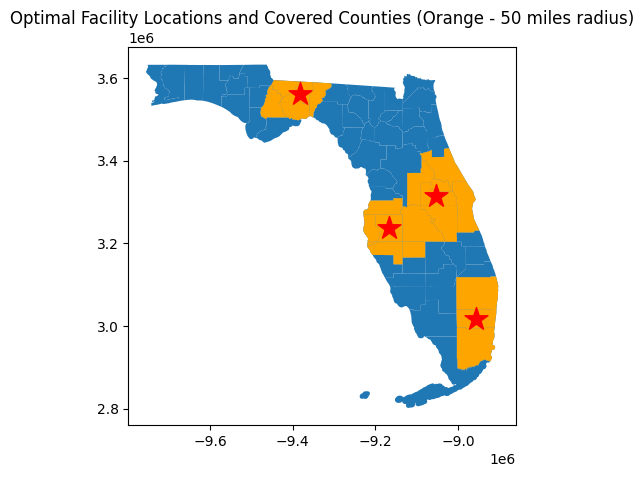

In [20]:
#Plot the faclities (stars) on top of the demand map.
fig, ax = plt.subplots(figsize=(5,5))

fl_counties.plot(ax=ax)

covered = (d[rslt,:] <= coverage_distance).sum(axis=0) >= 1

fl_counties.iloc[covered,].plot(ax=ax,color="orange")

facility_nodes.centroid.plot(ax=ax,color="red",markersize=300,marker="*")

plt.title("Optimal Facility Locations and Covered Counties (Orange - 50 miles radius)")
